*В этой работе будем использовать данные [с сайта елочных игрушек](https://www.eli.ru/catalog/elochnye-ukrasheniya/elochnye-igrushki/)*

##Загрузка данных

In [105]:
!pip install stargazer -q

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import statsmodels.api as sm
from stargazer.stargazer import Stargazer

#Сразу зададим цвета корреляционной матрицы
colors = ['#228B22', '#FFFFFF', '#DC143C']
n_bins = 100
cmap_name = 'green_red'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

#Зададим цвет всех графиков
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#008080'])

conn = sqlite3.connect("/content/eli.db")

products_df = pd.read_sql("SELECT * FROM products", conn)
categories_df = pd.read_sql("SELECT * FROM categories", conn)
characteristics_df = pd.read_sql("SELECT * FROM characteristics", conn)
product_characteristics_df = pd.read_sql("SELECT * FROM product_characteristics", conn)

conn.close()

Основная табличка $products\_df$, где есть название елочной игрушки ($name$), цена ($price$), сслыка на сайт ($url$), id категории ($category\_id$) и id товара ($id$)

In [106]:
products_df = products_df.drop(columns=['description'])
products_df.head()

,id,name,price,url,category_id
0,1,Елочная игрушка Конь Ринглинг - Circus Roncall...,1 600,/goods/steklyannaya-elochnaya-igrushka-cirkovo...,243.0
1,2,Набор елочных игрушек Снежинки Rainbow Glow 12...,290.0,/goods/nabor-elochnyh-igrushek-snezhinki-azhur...,2379.0
2,3,Набор елочных игрушек Сосульки - Loreto Apruti...,780.0,/goods/nabor-elochnyh-igrushek-sosulki-23-sm-4...,2379.0
3,4,Набор стеклянных елочных игрушек Palombara-Sab...,2 420,/goods/nabor-steklyannyh-elochnyh-igrushek-pal...,243.0
4,5,"Елочные игрушки Spettacolo Capodanno 23 см, 2 ...",1 950,/goods/nabor-steklyannyh-elochnyh-igrushek-spe...,243.0


Табличка $categories\_df$, в которой есть личный, локальный $id$ категории елочной игрушки ($id$), $id$ следующего родительского класса (т.е. смотрим как бы на уровень выше по категориям) ($parent\_id$), а также название категории ($name$)

In [107]:
categories_df.head()

,id,name,parent_id
0,1,Елочные украшения,0
1,2,Елочные игрушки,1
2,3,Шишки и желуди,2
3,30,Ангелы и Феи,2
4,39,"Бабочки, Жучки",2


Также $characteristics\_df$, в которой есть личный, локальный $id$ категории елочной игрушки ($id$), название характеристики ($name$), а также единицы исчисления характеристики ($unit$). Единицы исчисления включим в работу чуть позже, в разделе "Поработаем с признаками продуктов"

In [108]:
characteristics_df = characteristics_df.drop(columns='unit')
characteristics_df.head()

,id,name
0,1,Размер
1,2,Материал
2,3,Цвет
3,4,Тип крепления
4,5,Класс


И последняя табличка $product\_characteristics\_df$, в которой лежит локальный $id$ продукта ($product\_id$), $id$ характеристики продукта ($characteristic\_id$), а также значения характеристик товара ($value$)

In [109]:
product_characteristics_df.head()

,product_id,characteristic_id,value
0,6247,1,S (7-14 см)
1,6247,2,Акрил
2,6247,3,серебро
3,6247,4,подвеска
4,6247,5,премиум


##Начинаем чистить данные

In [110]:
#Почистим,где есть nan по id категориям
products_df = products_df.dropna(subset='category_id')

#Приведём к числовым данным эти id категорий
products_df['category_id'] = products_df['category_id'].astype(int)

In [111]:
'''
Унифицируем цены - убирем формат str, также поправим все пробелы и иные лишние знаки (напр., где 'от',
берем минимальную цену; альтернативно с 'до')
Также в вариантах, где сразу 2 цены (до скидки и после), оставим цены с скидкой
(чтобы быть более объективными в оценке значений в дальнейшем. ведь покупаем мы всегда с учетом скидок)
'''
def parse_price_to_min(value):

    text = str(value).strip().lower()

    #Неразрывные пробелы и т.п.
    text = text.replace("\xa0", " ")

    #Флаги "от"/"до" — нам нужны только как признак, но итог всё равно min
    is_from = text.startswith("от")
    is_to = text.startswith("до")

    # Срежем префикс "от"/"до", чтобы не мешал поиску чисел
    text_for_numbers = re.sub(r"^(от|до)\s*", "", text)

    # Убираем пробелы внутри числа: "1 600" -> "1600"
    text_for_numbers = re.sub(r"(?<=\d)\s+(?=\d)", "", text_for_numbers)

    # Ищем все числа (целые или с точкой/запятой)
    raw_nums = re.findall(r"\d+[.,]?\d*", text_for_numbers)
    if not raw_nums:
        return pd.NA

    nums = []
    for n in raw_nums:
        n_clean = n.replace(",", ".")
        try:
            nums.append(float(n_clean))
        except Exception:
            continue

    if not nums:
        return pd.NA

    return min(nums)

In [112]:
import re

products_df["price"] = products_df["price"].apply(parse_price_to_min)

In [113]:
#Проверим, что все в порядке по ценам
round(products_df["price"].describe(),2)

,price
count,8252.00
mean,1631.43
std,2395.81
min,50.00
25%,490.00
50%,1060.00
75%,1920.00
max,44460.00


In [114]:
#Что имеем сейчас по измененной табличке товаров
products_df.head()

,id,name,price,url,category_id
0,1,Елочная игрушка Конь Ринглинг - Circus Roncall...,1600.0,/goods/steklyannaya-elochnaya-igrushka-cirkovo...,243
1,2,Набор елочных игрушек Снежинки Rainbow Glow 12...,290.0,/goods/nabor-elochnyh-igrushek-snezhinki-azhur...,2379
2,3,Набор елочных игрушек Сосульки - Loreto Apruti...,780.0,/goods/nabor-elochnyh-igrushek-sosulki-23-sm-4...,2379
3,4,Набор стеклянных елочных игрушек Palombara-Sab...,2420.0,/goods/nabor-steklyannyh-elochnyh-igrushek-pal...,243
4,5,"Елочные игрушки Spettacolo Capodanno 23 см, 2 ...",1950.0,/goods/nabor-steklyannyh-elochnyh-igrushek-spe...,243


Да, все хорошо. Минимальные (50 руб) и максимальные (44460 руб) значения совпадают с теми, что на сайте: [min](https://www.eli.ru/goods/podveska-suvenir-raskras-i-podari-kit-6x7-sm-derevo/) и [max](https://www.eli.ru/goods/kollekcionnaya-kukla-mister-martines---vesennij-bal-v-strane-chudes-66-sm/)

##Работа с категориями


In [115]:
#Через табличку посмотрим на подкатегории, которые нас интересуют (как следующий слой дерева после "Елочные игрушки")
categories_df[categories_df['parent_id'] == 2]

,id,name,parent_id
2,3,Шишки и желуди,2
3,30,Ангелы и Феи,2
4,39,"Бабочки, Жучки",2
5,42,Банты на елку,2
19,413,Текстильные игрушки,2
21,417,Цветы,2
22,429,Елочки,2
23,438,Изысканные подвески,2
24,441,Колокольчики,2
25,447,Миниатюры,2


In [116]:
allowed_categories = set(categories_df[categories_df['parent_id'] == 2]['name'])

id_to_parent_all = dict(zip(categories_df['id'], categories_df['parent_id']))
id_to_name_all = dict(zip(categories_df['id'], categories_df['name']))

In [117]:
'''
Задаем функцию, с помощью которой будем идти от локальной категории товара вверх по дереву, вплоть до интересующей
категории елочных игрушек. Дальше просто присваиваем вместо категории в числе ее название
'''
collapse_cache_all = {}

def collapse_to_allowed_name(cat_id):
    if cat_id in collapse_cache_all:
        return collapse_cache_all[cat_id]

    current = cat_id
    depth_limit = 5
    for _ in range(depth_limit):
        name = id_to_name_all.get(current)
        if name in allowed_categories:
            collapse_cache_all[cat_id] = name
            return name

        parent = id_to_parent_all.get(current)
        if parent is None or parent == 1:
            collapse_cache_all[cat_id] = None
            return None

        current = parent

    collapse_cache_all[cat_id] = None
    return None


In [118]:
products_df['category_name'] = products_df['category_id'].apply(collapse_to_allowed_name)
products_df = products_df.drop(columns='category_id')
products_df = products_df[products_df['category_name'].notna()]

In [119]:
products_df = products_df.reset_index(drop=True)
products_df.head()

,id,name,price,url,category_name
0,24,"Елочная игрушка Енотик Дэнни 9 см, подвеска",1580.0,/goods/elochnaya-igrushka-enotik-djenni-9-sm-p...,Животные
1,28,Елочная игрушка Бабочка Иви - Azure Wonders 10 см,970.0,/goods/elochnaya-igrushka-babochka-sharlotta-1...,"Бабочки, Жучки"
2,33,Елочная игрушка Christmas Bakery - Лошадка 9 с...,340.0,/goods/elochnaya-igrushka-christmas-bakery-los...,Символ года 2026
3,38,Елочная игрушка Цветок Jasmia 28 см,1610.0,/goods/elochnaya-igrushka-cvetok-jasmia-28-sm-...,Цветы
4,44,Елочная игрушка Эльф Анри - Помощник Санты 12 ...,2620.0,/goods/elochnaya-igrushka-jelf-anri---pomoshhn...,Гномы и Эльфы


In [120]:
products_df.shape

(2621, 5)

После такого "хождения" по дереву категорий у нас осталось около трех тысяч наблюдений от прежних 8+, хотя весь парсинг был с страницы, приложенной в начале работы

Значит, датабаза самого магазина может быть устроена "грязно" и некоторые товары имеют путь, исходный узел которого на самом деле не "Елочные игрушки"



##Поработаем с признаками продуктов

In [121]:
#Возьмем топ-10 признаков, чаще всего встречающихся в товарах (и с описания, и с самих характеристик)
top_characteristics = (product_characteristics_df
                      .groupby('characteristic_id')
                      .size()
                      .reset_index(name='count')
                      .sort_values('count', ascending=False)
                      .head(10))
top_char = top_characteristics['characteristic_id'].tolist()

#Создадим кортежи типа (индекс признака в табличке всех признаков, название признака)
filtered_characteristics_df = characteristics_df[characteristics_df['id'].isin(top_char)]
result = dict(list(zip(filtered_characteristics_df['id'], filtered_characteristics_df['name'])))
result

{1: 'Размер',
 2: 'Материал',
 3: 'Цвет',
 5: 'Класс',
 7: 'Набор',
 8: 'Подсветка',
 29: 'Вес',
 30: 'Объем упаковки',
 31: 'Страна производства',
 32: 'Страна бренда'}

In [122]:
#Теперь оставим только выбранные признаки в табличке c товарами и их признаками
needed_ids = list(result.keys())
product_characteristics_df = product_characteristics_df[product_characteristics_df['characteristic_id'].isin(needed_ids)]

In [123]:
product_characteristics_df

,product_id,characteristic_id,value
0,6247,1,S (7-14 см)
1,6247,2,Акрил
2,6247,3,серебро
4,6247,5,премиум
5,6247,7,Нет
...,...,...,...
122042,2046,3,красный / бордовый
122043,15038,3,красный / бордовый
122044,13933,3,разноцветные
122045,15057,3,разноцветные


In [124]:
#Теперь сделаем таблицу формата (id товара, параметры)
params_df = product_characteristics_df.pivot(
    index='product_id',
    columns='characteristic_id',
    values='value').reset_index()

params_df.columns.name = None
rename_dict = {'product_id': 'product_id'}
rename_dict.update(result)

params_df = params_df.rename(columns=rename_dict)
print(params_df.shape)

params_df.head()

(8259, 11)


,product_id,Размер,Материал,Цвет,Класс,Набор,Подсветка,Вес,Объем упаковки,Страна производства,Страна бренда
0,1,S (7-14 см),Стекло,кремовый / светлое дерево,премиум,Нет,Нет,0.28 кг,0.0023 м 3,Китай,Россия
1,2,S (7-14 см),Акрил,золото,эконом,Да,Нет,0.08 кг,0.0003 м 3,Китай,Россия
2,3,M (15-30 см),Акрил,прозрачный,эконом,Да,Нет,0.15 кг,0.0004 м 3,Китай,Россия
3,4,M (15-30 см),Стекло,разноцветные,премиум,Да,Нет,0.28 кг,0.0046 м 3,Китай,Россия
4,5,M (15-30 см),Стекло,золото,премиум,Да,Нет,0.2 кг,0.0035 м 3,Китай,Россия


In [125]:
#Сразу зачистим от строк с хотя бы 1 пропуском - значений много, можем позволить :)
params_df = params_df.dropna()
print(params_df.shape)

params_df.head()

(6830, 11)


,product_id,Размер,Материал,Цвет,Класс,Набор,Подсветка,Вес,Объем упаковки,Страна производства,Страна бренда
0,1,S (7-14 см),Стекло,кремовый / светлое дерево,премиум,Нет,Нет,0.28 кг,0.0023 м 3,Китай,Россия
1,2,S (7-14 см),Акрил,золото,эконом,Да,Нет,0.08 кг,0.0003 м 3,Китай,Россия
2,3,M (15-30 см),Акрил,прозрачный,эконом,Да,Нет,0.15 кг,0.0004 м 3,Китай,Россия
3,4,M (15-30 см),Стекло,разноцветные,премиум,Да,Нет,0.28 кг,0.0046 м 3,Китай,Россия
4,5,M (15-30 см),Стекло,золото,премиум,Да,Нет,0.2 кг,0.0035 м 3,Китай,Россия


Как видим, после "чистки данных" на пропуски ушло около 1.5k наблюдений

In [126]:
#Уберем единицы измерения в весе товара и объеме упаковки (просто запомним, что это кг и м^3 соотв.)
params_df['Вес'] = params_df['Вес'].str.replace(' кг', '').astype(float)
params_df['Объем упаковки'] = params_df['Объем упаковки'].str.replace(' м 3', '').astype(float)

In [127]:
#Проверяем параметры на дубли по id
params_df.duplicated(subset=['product_id']).sum()

np.int64(0)

In [128]:
#На всякий случай сверим, что id товаров совпадает с исходными данными (напр., по 1-ому продукту в готовом params_df)
print(params_df.iloc[0])
print(product_characteristics_df[product_characteristics_df['product_id'] == 1])

product_id                                     1
Размер                               S (7-14 см)
Материал                                  Стекло
Цвет                   кремовый / светлое дерево
Класс                                    премиум
Набор                                        Нет
Подсветка                                    Нет
Вес                                         0.28
Объем упаковки                            0.0023
Страна производства                        Китай
Страна бренда                             Россия
Name: 0, dtype: object
       product_id  characteristic_id                      value
98247           1                  1                S (7-14 см)
98248           1                  2                     Стекло
98251           1                 29                    0.28 кг
98255           1                 30                 0.0023 м 3
98256           1                 31                      Китай
98257           1                 32                  

Да, супер, все совпало! Теперь соединим обе таблички по id товаров

In [129]:
#Берем только товары, у которых есть характеристики!
products_merged = pd.merge(products_df,
                           params_df,
                           left_on='id',
                           right_on='product_id',
                           how='inner')
products_merged = products_merged.drop('product_id', axis=1)
print(products_merged.shape)
products_merged.head()

(2373, 15)


,id,name,price,url,category_name,Размер,Материал,Цвет,Класс,Набор,Подсветка,Вес,Объем упаковки,Страна производства,Страна бренда
0,24,"Елочная игрушка Енотик Дэнни 9 см, подвеска",1580.0,/goods/elochnaya-igrushka-enotik-djenni-9-sm-p...,Животные,S (7-14 см),Полистоун,шоколадный / коричневый,премиум,Нет,Нет,0.10,0.0003,Китай,Нидерланды
1,28,Елочная игрушка Бабочка Иви - Azure Wonders 10 см,970.0,/goods/elochnaya-igrushka-babochka-sharlotta-1...,"Бабочки, Жучки",S (7-14 см),Пластик,бирюзовый,премиум,Нет,Нет,0.04,0.0003,Китай,Нидерланды
2,33,Елочная игрушка Christmas Bakery - Лошадка 9 с...,340.0,/goods/elochnaya-igrushka-christmas-bakery-los...,Символ года 2026,S (7-14 см),Керамика / Фарфор,красный / бордовый,стандарт,Нет,Нет,0.04,0.0002,Китай,Нидерланды
3,38,Елочная игрушка Цветок Jasmia 28 см,1610.0,/goods/elochnaya-igrushka-cvetok-jasmia-28-sm-...,Цветы,M (15-30 см),Текстиль,розовый,премиум,Нет,Нет,0.02,0.0004,Таиланд,Бельгия
4,44,Елочная игрушка Эльф Анри - Помощник Санты 12 ...,2620.0,/goods/elochnaya-igrushka-jelf-anri---pomoshhn...,Гномы и Эльфы,S (7-14 см),Полистоун,красный / бордовый,премиум,Нет,Нет,0.09,0.0004,Китай,Бельгия


In [130]:
#Проверяем на полные дубли всю финальную таблицу
print(products_merged.duplicated().sum())

#Проверяем на дубли все id в финальной таблице
print(products_merged.duplicated(subset=['id']).sum())

0
0


In [131]:
#Проверяем на пропуски всю финальную таблицу
print(products_merged.isna().sum())

id                     0
name                   0
price                  0
url                    0
category_name          0
Размер                 0
Материал               0
Цвет                   0
Класс                  0
Набор                  0
Подсветка              0
Вес                    0
Объем упаковки         0
Страна производства    0
Страна бренда          0
dtype: int64


In [132]:
#Проверяем на типы данных финальную таблицу
print(products_merged.dtypes)

id                       int64
name                    object
price                  float64
url                     object
category_name           object
Размер                  object
Материал                object
Цвет                    object
Класс                   object
Набор                   object
Подсветка               object
Вес                    float64
Объем упаковки         float64
Страна производства     object
Страна бренда           object
dtype: object


In [133]:
#Проверяем, чтобы переменные не были равны 0
print((products_merged['Вес'] == 0).sum())
print((products_merged['Объем упаковки'] == 0).sum())
print((products_merged['price'] == 0).sum())

2
48
0


In [134]:
#Удаляем лишнее, чтобы не мешало анализу
products_merged = products_merged[products_merged['Вес'] != 0]
products_merged = products_merged[products_merged['Объем упаковки'] != 0]

Все, базовая обработка закончена - дальше только метрика!

In [135]:
#Сохраним табличку в csv-формат
products_merged.to_csv('eli.csv')

## Предварительный анализ данных, EDA

In [136]:
df = pd.read_csv('eli.csv', index_col=0)
df.head()

,id,name,price,url,category_name,Размер,Материал,Цвет,Класс,Набор,Подсветка,Вес,Объем упаковки,Страна производства,Страна бренда
0,24,"Елочная игрушка Енотик Дэнни 9 см, подвеска",1580.0,/goods/elochnaya-igrushka-enotik-djenni-9-sm-p...,Животные,S (7-14 см),Полистоун,шоколадный / коричневый,премиум,Нет,Нет,0.10,0.0003,Китай,Нидерланды
1,28,Елочная игрушка Бабочка Иви - Azure Wonders 10 см,970.0,/goods/elochnaya-igrushka-babochka-sharlotta-1...,"Бабочки, Жучки",S (7-14 см),Пластик,бирюзовый,премиум,Нет,Нет,0.04,0.0003,Китай,Нидерланды
2,33,Елочная игрушка Christmas Bakery - Лошадка 9 с...,340.0,/goods/elochnaya-igrushka-christmas-bakery-los...,Символ года 2026,S (7-14 см),Керамика / Фарфор,красный / бордовый,стандарт,Нет,Нет,0.04,0.0002,Китай,Нидерланды
3,38,Елочная игрушка Цветок Jasmia 28 см,1610.0,/goods/elochnaya-igrushka-cvetok-jasmia-28-sm-...,Цветы,M (15-30 см),Текстиль,розовый,премиум,Нет,Нет,0.02,0.0004,Таиланд,Бельгия
4,44,Елочная игрушка Эльф Анри - Помощник Санты 12 ...,2620.0,/goods/elochnaya-igrushka-jelf-anri---pomoshhn...,Гномы и Эльфы,S (7-14 см),Полистоун,красный / бордовый,премиум,Нет,Нет,0.09,0.0004,Китай,Бельгия


In [137]:
df_filtered_d = df.copy()
df_filtered_d = df_filtered_d.drop(columns='id')
df_filtered_d.describe()


,price,Вес,Объем упаковки
count,2323.000000,2323.000000,2323.000000
mean,1581.869565,0.101192,0.001685
std,3136.269118,0.167513,0.003542
min,50.000000,0.010000,0.000100
25%,420.000000,0.030000,0.000300
50%,790.000000,0.070000,0.000600
75%,1720.000000,0.105000,0.001500
max,44460.000000,2.200000,0.080600


Среднее везде значительно выше, чем медиана, это указывает на несимметричность распределений. У цены огромное стандартное отклонение(больше средней цены). Построим графики распределений, чтобы лучше разобраться.

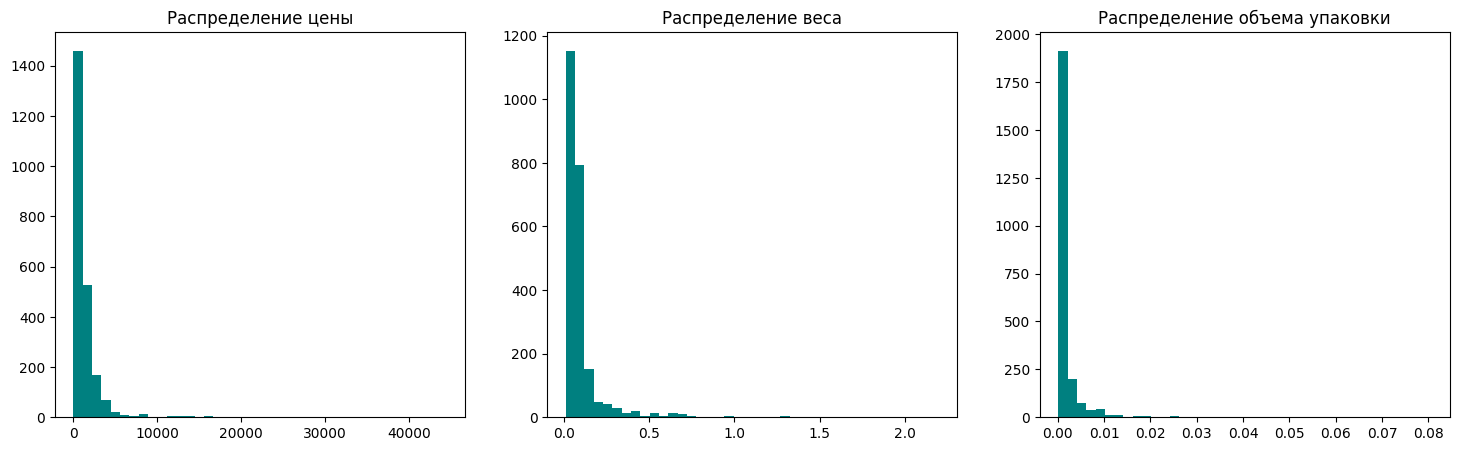

In [138]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['price'], bins=40)
axes[0].set_title('Распределение цены')

axes[1].hist(df['Вес'], bins=40)
axes[1].set_title('Распределение веса')

axes[2].hist(df['Объем упаковки'], bins=40)
axes[2].set_title('Распределение объема упаковки')

plt.show()


* Цены товаров часто распределены правосторонне, в данных много дешевых и всего несколько дорогих товаров, это приводит к большим выбросам, которые ухудшают качество модели. Поэтому следует взять натуральный логарифм от зависимой переменной, тогда объясняющие переменные будут взлиять на изменение цены в %.
* Как можно заметить по графикам, распределения веса игрушки и объема упаковки тоже смещены вправо, поэтому их тоже стоит прологарифмировать.
* Но вначале стоит привести их к удобным единицам измерения(изначально вес задн в долях килограмма, а объем - в долях кубического метра), для адекватной интерпретации модели переведем все в граммы и литры соответственно.

In [139]:
df['Объем упаковки'] = df['Объем упаковки'] * 1000 #переводим в литры
df['Вес'] = df['Вес'] * 1000 #переводим в граммы
df['ln_Вес'] = np.log(df['Вес'])
df['ln_Объем упаковки'] = np.log(df['Объем упаковки'])
df['ln_price'] = np.log(df['price'])

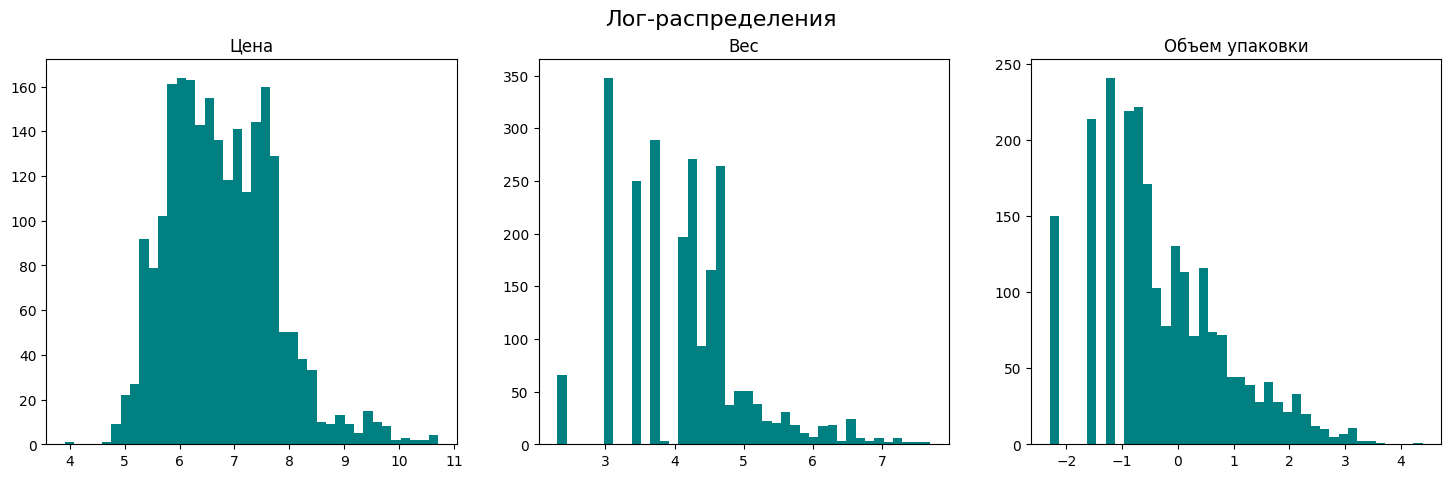

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['ln_price'], bins=40)
axes[0].set_title('Цена')
axes[1].hist(df['ln_Вес'], bins=40)
axes[1].set_title('Вес')
axes[2].hist(df['ln_Объем упаковки'], bins=40)
axes[2].set_title('Объем упаковки')
fig.suptitle('Лог-распределения', fontsize=16)

plt.show()

* Можно заметить, что после логафмирования распределение цены стало более симметричным, даже похожим на нормальное, выбросы справа не так сильно выделяются.
* В распределение веса резко выраженные столбики, это не является проблемой, тк производители выпускают товары фиксированного веса.
* В распределение объема сильный хвост справа, также сильно выделяются несколько значений, переменная может быть менее информативна при оценке модели.

Теперь посмотрим на наши категориальные данные:

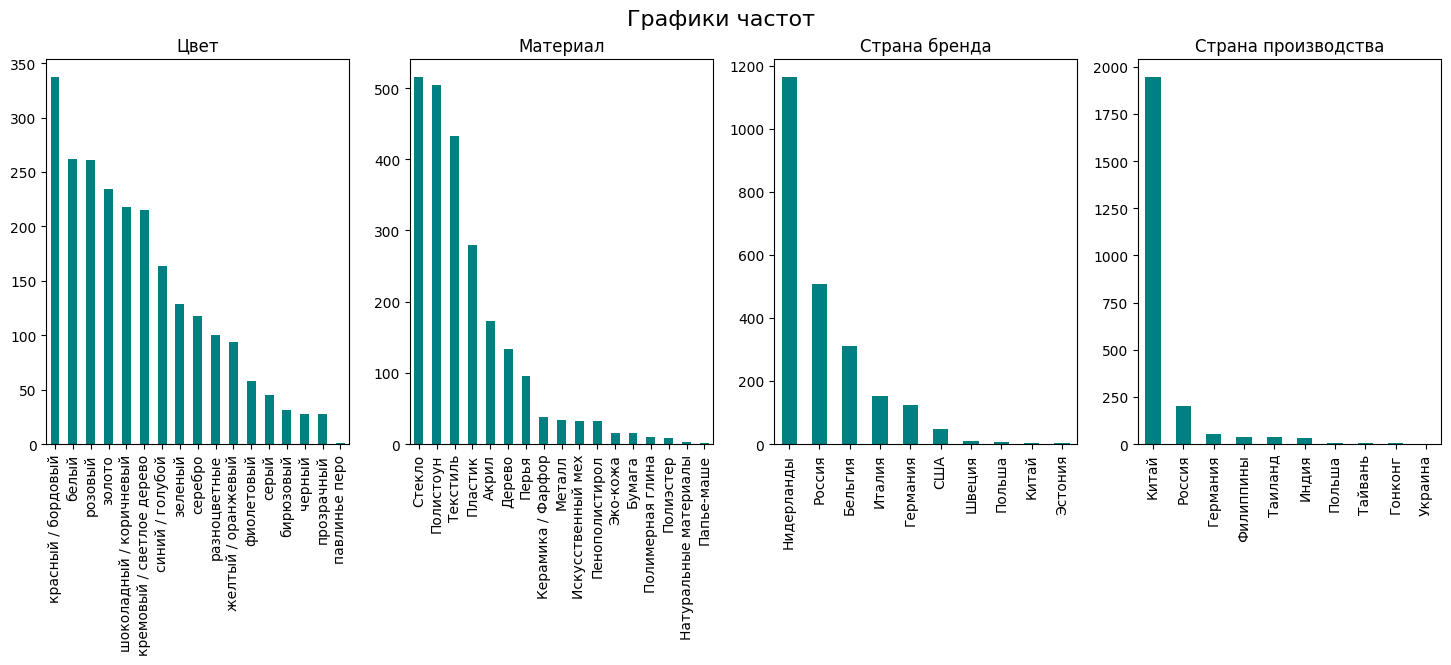

In [141]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

fig.suptitle('Графики частот', fontsize=16)
columns = ['Цвет', 'Материал', 'Страна бренда', 'Страна производства']
for ax, col in zip(axes, columns):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

plt.show()

Все категориальные переменные содержат слишком много уникальных значений, для корректного построения регрессионной модели стоит разбить признаки на группы.

In [142]:
def group_color(x):
    if x in ['красный / бордовый', 'золото', 'шоколадный / коричневый', 'серебро', 'белый', 'прозрачный', 'разноцветные']:
        return 'новогодний'
    return 'неновогодний'

df['Группа цвет'] = df['Цвет'].apply(group_color)

In [143]:
def group_material(x):
    if x in ['Стекло', 'Керамика / Фарфор', 'Металл','Полистоун']:
        return 'классика'
    if x in ['Пластик', 'Акрил', 'Пенополистирол', 'Полиэстер']:
        return 'полимеры'
    if x in ['Текстиль', 'Дерево', 'Перья', 'Искусственный мех', 'Эко-кожа', 'Бумага',
             'Натуральные материалы', 'Папье-маше']:
        return 'эко'

df["Группа материал"] = df["Материал"].apply(group_material)


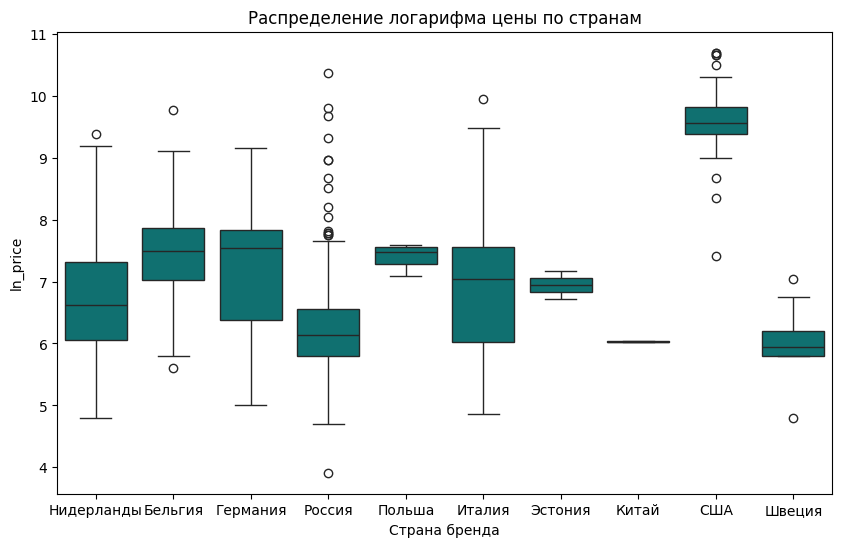

In [144]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Страна бренда', y='ln_price', data=df)
plt.title('Распределение логарифма цены по странам')
plt.show()

Придется выделить США в отдельную категорию, тк цена у этих брендов сильно выше,чем у остальных.

In [145]:
def group_country_brand(x):
    eu = ['Германия', 'Италия', 'Бельгия', 'Швеция']
    if x in eu:
        return 'Европа'
    if x == 'Россия':
        return 'Россия'
    if x == 'Нидерланды':
      return 'Нидерланды'
    if x == 'США':
      return 'США'
    return 'Другие'

df['Группа страна'] = df["Страна бренда"].apply(group_country_brand)

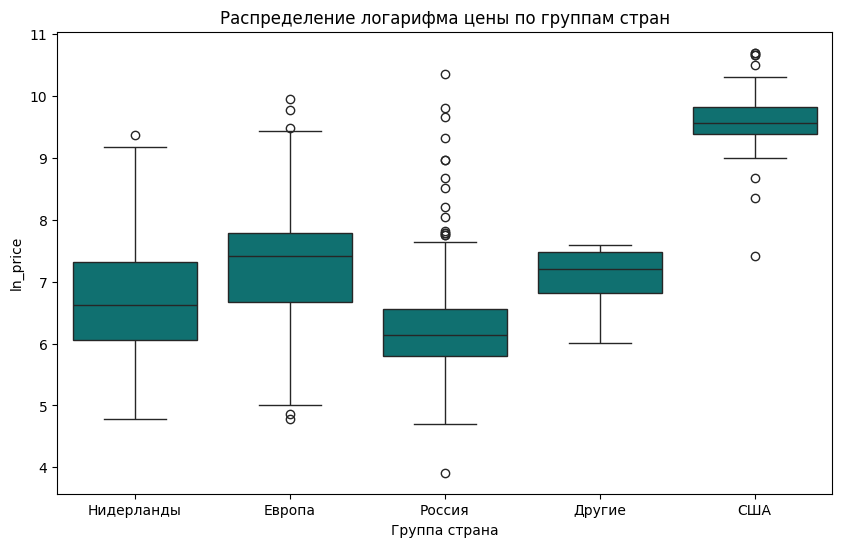

In [146]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Группа страна', y='ln_price', data=df)
plt.title('Распределение логарифма цены по группам стран')
plt.show()

Выделим Китай отдельно от остальных стран производителей, это понадобится для проверки гипотез в дальнейшем.

In [147]:
def group_country_prod(x):
    if x == 'Китай':
        return 'Китай'
    return 'Другие'

df["Группа производитель"] = df["Страна производства"].apply(group_country_prod)

In [148]:
def group_size(x):
    if x in ['XS (до 6 см)']:
        return 'маленькие'
    if x in ['L (31-50 см)', 'XL (51-80 см)', 'XXL (81 см и более)']:
        return 'большие'
    if x in ['14 см.', 'S (7-14 см)', 'M (15-30 см)']:
        return 'средние'
df['Группа размер'] = df["Размер"].apply(group_size)

## Построение регрессионной модели

In [149]:
# Применим к нашим категориальным данным one-hot кодирование
df = pd.get_dummies(df, columns=['Группа материал'], drop_first=False)
df = pd.get_dummies(df, columns=['Класс'], drop_first=False)
df = pd.get_dummies(df, columns=['Группа страна'], drop_first=False)
df = pd.get_dummies(df, columns=['Группа размер'], drop_first=False)
df = pd.get_dummies(df, columns=['Группа цвет'], drop_first=False)

#убираем не любой признак, а основной, чтобы интерпретация была логичнее
df = df.drop(columns=['Группа материал_классика'])
df = df.drop(columns=['Класс_стандарт'])
df = df.drop(columns=['Группа размер_средние'])
df = df.drop(columns=['Группа страна_Нидерланды'])
df = df.drop(columns=['Группа цвет_неновогодний'])


df['Набор'] = df['Набор'].map({'Да':1,'Нет':0})
df['Подсветка'] = df['Подсветка'].map({'Да':1,'Нет':0})
df['Группа производитель'] = df['Группа производитель'].map({'Китай':1,'Другие':0})

dummy_cols = [col for col in df.columns if df[col].dtype == 'bool']
df[dummy_cols] = df[dummy_cols].astype(int)

Создадим новую таблицу, где соберем все переменные для регрессии.

In [150]:
df_reg = df.drop(columns=['Вес', 'Объем упаковки', 'category_name', 'price',
                          'id', 'name', 'url', 'Цвет', 'Материал', 'Страна производства',
                          'Страна бренда', 'Размер'])
df_reg.head()

,Набор,Подсветка,ln_Вес,ln_Объем упаковки,ln_price,Группа производитель,Группа материал_полимеры,Группа материал_эко,Класс_премиум,Класс_эконом,Группа страна_Другие,Группа страна_Европа,Группа страна_Россия,Группа страна_США,Группа размер_большие,Группа размер_маленькие,Группа цвет_новогодний
0,0,0,4.605170,-1.203973,7.365180,1,0,0,1,0,0,0,0,0,0,0,1
1,0,0,3.688879,-1.203973,6.877296,1,1,0,1,0,0,0,0,0,0,0,0
2,0,0,3.688879,-1.609438,5.828946,1,0,0,0,0,0,0,0,0,0,0,1
3,0,0,2.995732,-0.916291,7.383989,0,0,1,1,0,0,1,0,0,0,0,0
4,0,0,4.499810,-0.916291,7.870930,1,0,0,1,0,0,1,0,0,0,0,1


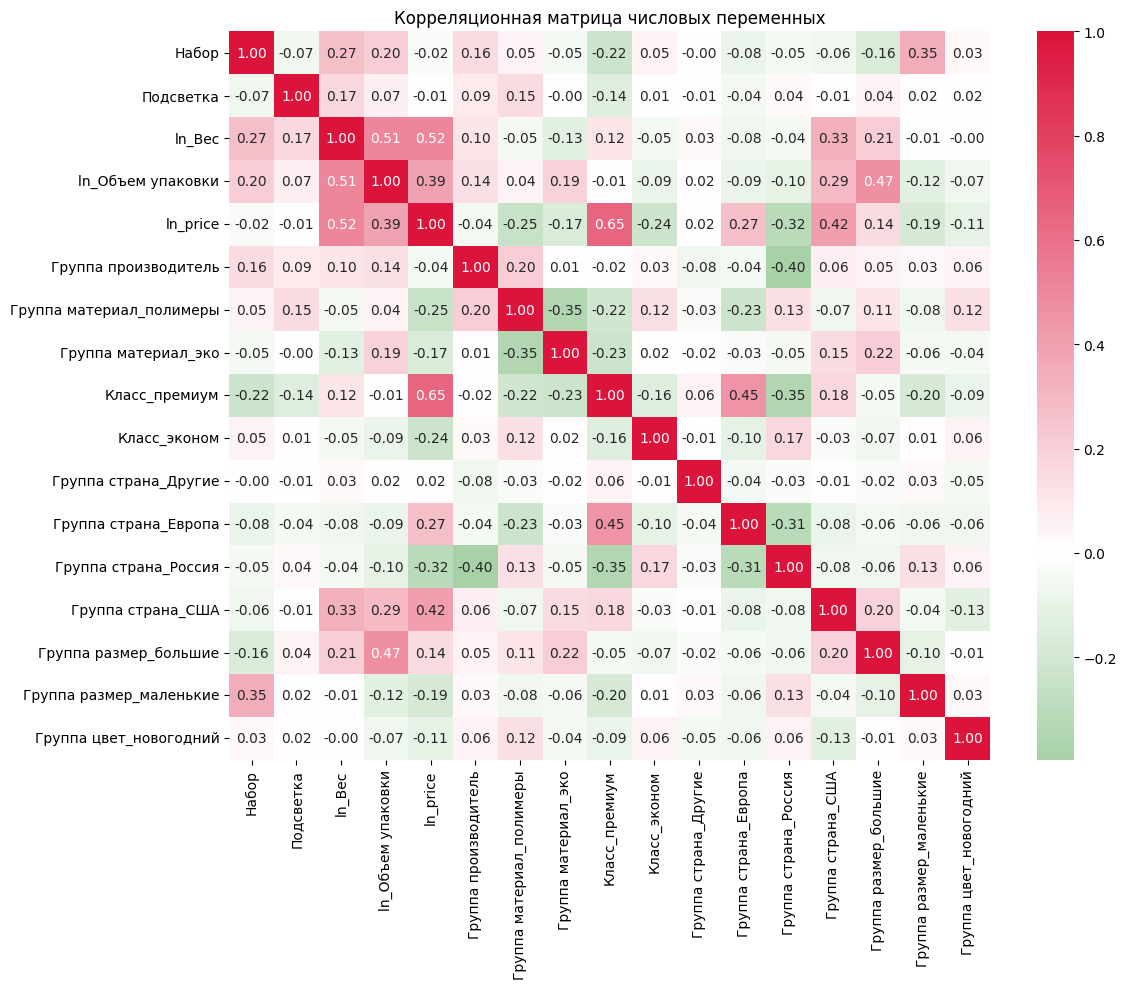

In [151]:
corr = df_reg.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap=cm, center=0, annot=True, fmt=".2f")
plt.title("Корреляционная матрица числовых переменных")

plt.tight_layout()
plt.show()

In [152]:
X = df_reg.drop(columns=['ln_price'])
y = df_reg['ln_price']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     421.4
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:23:12   Log-Likelihood:                -1628.5
No. Observations:                2323   AIC:                             3291.
Df Residuals:                    2306   BIC:                             3389.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

Сделаем красивую табличку)

In [153]:
stargazer = Stargazer([model])
stargazer.title("Regression results")

latex = stargazer.render_latex()
latex = latex.replace("_", r"\_")

with open("regression.tex", "w") as f:
    f.write(latex)